# SDN-MPLS-ML Tech Demonstrator: XGBoost Training and Validation Notebook

> El presente notebook de entrenamiento para el clasificador multiclass de trafico SDNFlow usando XGBoost y Optuna esta disenado para incluir todas las secciones de entrenamiento en un mismo documento, unsando Optuna como la libreria para optimizar hiperparametros y al final la libreria de XGBoost no Sklearn para producir un modelo que puede ser exportado como en formato JSON para cargarlo en una API.

1. El objetivo de este notebook es entrenar un modelo que use exactamente las variables de primer paquete:
    - `eth_type`
    - `ip_proto`
    - `src_port`
    - `dst_port`

    y prediga la variable objetivo:
    - `Category`
2. El dataset presenta desbalance fuerte de clases. Por esa razon el notebook usa:

- `macro-F1` como metrica primaria;
- `sample_weight` balanceado por clase durante entrenamiento;
- `StratifiedShuffleSplit` para hold-out 70/30;
- `StratifiedKFold` de 5 folds dentro del conjunto de entrenamiento;
- reportes por clase y matriz de confusion normalizada.


## Seccion 1: Definicion de Librerias, variables y funciones auxiliares


### Carga de Librerias


In [11]:
#! Carga de librerias y modulos base del notebook.

from __future__ import annotations

import json
import math
import os
import platform
import random
import re
import sys
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import xgboost as xgb

from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")


In [2]:
#! Impresiones de ayuda para registrar el entorno de ejecucion.

print(f"Python: {sys.version}")
print(f"Plataforma: {platform.platform()}")
print(f"Arquitectura: {platform.machine()}")
print(f"Procesadores logicos detectados: {os.cpu_count()}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"xgboost: {xgb.__version__}")
print(f"optuna: {optuna.__version__}")


Python: 3.13.13 (main, Apr  7 2026, 18:19:01) [Clang 21.0.0 (clang-2100.0.123.102)]
Plataforma: macOS-26.5.1-arm64-arm-64bit-Mach-O
Arquitectura: arm64
Procesadores logicos detectados: 16
pandas: 3.0.5
numpy: 2.5.1
xgboost: 3.3.0
optuna: 4.9.0


### Definicion de variables de configuracion del notebook


In [3]:
#! Configuraciones principales de entrada, salida y reproducibilidad.
#! El usuario debe modificar solamente este bloque para apuntar al dataset limpio.

DATA_PATH = Path("../../../res/data/processed/SDNFlow_Training_Sample_Dataset.csv")
OUTPUT_DIR = Path("../../../res/models")

MODEL_FILENAME = "sdn_mpls_ml_model.json"
MODEL_METADATA_FILENAME = "sdn_mpls_ml_model_meta.json"
FINAL_METRICS_FILENAME = "sdn_mpls_ml_final_metrics.json"
OPTUNA_TRIALS_FILENAME = "sdn_mpls_mp_optuna_trials.csv"
TRAIN_TEST_SPLIT_FILENAME = "sdn_mpls_ml_train_test_split_summary.json"

CSV_ENCODING = "utf-8"
CSV_SEPARATOR = ","

RANDOM_STATE = 42

#! Hold-out principal definido en el plan: 70% entrenamiento, 30% prueba.
TEST_SIZE = 0.30

#! Validacion cruzada definida en el plan: 5 folds estratificados.
N_SPLITS = 5

#! Numero inicial recomendado de trials.
#! Con 221K filas, 4 features y CPU local, 75 trials es un balance razonable
#! entre cobertura de busqueda y costo computacional.
N_OPTUNA_TRIALS = 75

#! Optuna se ejecuta secuencialmente para evitar sobrecargar CPU.
#! Cada fit de XGBoost puede usar varios threads.
OPTUNA_N_JOBS = 1

#! Threads de XGBoost.
#! Se deja un core libre cuando es posible para mantener estable el sistema.
XGB_N_JOBS = max(1, (os.cpu_count() or 2) - 1)

#! Rondas maximas durante Optuna.
#! Early stopping elegira la cantidad efectiva por fold.
MAX_BOOSTING_ROUNDS = 1200
EARLY_STOPPING_ROUNDS = 50

#! Tolerancia para validar probabilidades.
PROBABILITY_SUM_TOLERANCE = 1e-3

#! Control de figuras.
SAVE_FIGURES = True
FIGURES_DIR = OUTPUT_DIR / "figures"

#! Control del estudio de Optuna.
OPTUNA_STUDY_NAME = "sdnflow_xgboost_multiclass_macro_f1"
OPTUNA_STORAGE = None


### Definiciones de constantes de datos del notebook


In [4]:
#! Definicion canonica de variables de entrada y clases.
#! Este orden debe ser identico al usado por la API de inferencia.

FEATURE_COLUMNS = [
    "eth_type",
    "ip_proto",
    "src_port",
    "dst_port",
]

TARGET_COLUMN = "Category"

EXPECTED_CLASSES = [
    "DNS",
    "FTP",
    "HTTP",
    "ICMP",
    "NTP",
    "SSH",
    "STREAMING",
]

CLASS_TO_ID = {
    class_name: class_id
    for class_id, class_name in enumerate(EXPECTED_CLASSES)
}

ID_TO_CLASS = {
    str(class_id): class_name
    for class_name, class_id in CLASS_TO_ID.items()
}

TRAINING_COLUMNS = FEATURE_COLUMNS + [TARGET_COLUMN]

EXPECTED_CLASS_DISTRIBUTION_FROM_EDA = {
    "HTTP": {"count": 164974, "percentage": 74.458847, "rank": 1},
    "DNS": {"count": 53551, "percentage": 24.169540, "rank": 2},
    "STREAMING": {"count": 1487, "percentage": 0.671138, "rank": 3},
    "SSH": {"count": 1133, "percentage": 0.511365, "rank": 4},
    "ICMP": {"count": 305, "percentage": 0.137658, "rank": 5},
    "FTP": {"count": 91, "percentage": 0.041072, "rank": 6},
    "NTP": {"count": 23, "percentage": 0.010381, "rank": 7},
}

#! Rangos permitidos por variable.
FEATURE_RULES = {
    "eth_type": {"min": 0, "max": 65535},
    "ip_proto": {"min": 0, "max": 255},
    "src_port": {"min": 0, "max": 65535},
    "dst_port": {"min": 0, "max": 65535},
}


### Utilidades del notebook


In [5]:
def normalize_category_series(series: pd.Series) -> pd.Series:
    """Normaliza las etiquetas de la variable objetivo.

    Paso a paso:

    1. Convierte la serie al tipo string nullable de Pandas.
    2. Elimina espacios al inicio y al final.
    3. Convierte las etiquetas a mayusculas.
    4. Sustituye marcadores textuales de nulidad por pd.NA.
    5. Devuelve la serie normalizada.

    Args:
        series: Serie con etiquetas originales.

    Returns:
        Serie normalizada con etiquetas en mayusculas.
    """
    #! Convierte la columna a texto nullable para preservar pd.NA.
    normalized = series.astype("string")

    #! Elimina espacios al inicio y al final de cada etiqueta.
    normalized = normalized.str.strip()

    #! Uniforma la representacion de clases usando mayusculas.
    normalized = normalized.str.upper()

    #! Define marcadores textuales que deben tratarse como nulos.
    null_markers = {"", "NULL", "NONE", "NAN", "NA", "N/A", "?"}

    #! Reemplaza los marcadores textuales por pd.NA.
    normalized = normalized.mask(normalized.isin(null_markers), pd.NA)

    #! Devuelve la serie lista para validar contra EXPECTED_CLASSES.
    return normalized


def validate_configuration() -> None:
    """Valida las rutas y parametros principales antes de ejecutar el notebook.

    Paso a paso:

    1. Verifica que DATA_PATH haya sido reemplazado.
    2. Verifica que OUTPUT_DIR haya sido reemplazado.
    3. Verifica que el archivo de entrada exista.
    4. Verifica que el archivo de entrada sea un archivo regular.
    5. Verifica que TEST_SIZE este entre 0 y 1.
    6. Verifica que N_SPLITS sea al menos 2.
    7. Verifica que N_OPTUNA_TRIALS sea positivo.
    8. Crea OUTPUT_DIR y FIGURES_DIR si corresponde.

    Raises:
        ValueError: Si un parametro no es valido.
        FileNotFoundError: Si el dataset no existe.
        IsADirectoryError: Si DATA_PATH no apunta a un archivo.
    """
    #! Evita ejecutar el notebook con la ruta placeholder.
    if str(DATA_PATH).startswith("<USER_TO_DEFINE"):
        raise ValueError("DATA_PATH debe reemplazarse por la ruta del CSV limpio.")

    #! Evita ejecutar el notebook con el directorio placeholder.
    if str(OUTPUT_DIR).startswith("<USER_TO_DEFINE"):
        raise ValueError("OUTPUT_DIR debe reemplazarse por un directorio real.")

    #! Confirma que el archivo de entrada exista.
    if not DATA_PATH.exists():
        raise FileNotFoundError(f"No existe el dataset: {DATA_PATH}")

    #! Confirma que la ruta corresponda a un archivo.
    if not DATA_PATH.is_file():
        raise IsADirectoryError(f"DATA_PATH no apunta a un archivo: {DATA_PATH}")

    #! Verifica que el tamano de prueba sea una proporcion valida.
    if not 0.0 < TEST_SIZE < 1.0:
        raise ValueError("TEST_SIZE debe estar entre 0 y 1.")

    #! Verifica que la validacion cruzada tenga al menos 2 folds.
    if N_SPLITS < 2:
        raise ValueError("N_SPLITS debe ser al menos 2.")

    #! Verifica que Optuna ejecute al menos un trial.
    if N_OPTUNA_TRIALS <= 0:
        raise ValueError("N_OPTUNA_TRIALS debe ser mayor que cero.")

    #! Crea el directorio de salida.
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    #! Crea el directorio de figuras cuando esta habilitado.
    if SAVE_FIGURES:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def finalize_figure(name: str | None = None) -> None:
    """Ajusta, guarda opcionalmente, muestra y cierra la figura activa.

    Args:
        name: Nombre logico de archivo sin extension.

    Returns:
        None.
    """
    #! Ajusta margenes para evitar etiquetas recortadas.
    plt.tight_layout()

    #! Guarda la figura solo cuando se habilita y se entrega nombre.
    if SAVE_FIGURES and name:
        #! Sanitiza el nombre del archivo para evitar caracteres problematicos.
        safe_name = re.sub(r"[^A-Za-z0-9._-]+", "_", name).strip("._")

        #! Crea el directorio por seguridad.
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)

        #! Guarda la figura en formato PNG.
        plt.savefig(FIGURES_DIR / f"{safe_name}.png", dpi=180, bbox_inches="tight")

    #! Muestra la figura dentro del notebook.
    plt.show()

    #! Cierra la figura para liberar memoria.
    plt.close()


def display_class_distribution(y: pd.Series, title: str) -> pd.DataFrame:
    """Construye y muestra una tabla de distribucion de clases.

    Paso a paso:

    1. Cuenta las ocurrencias por clase.
    2. Calcula porcentajes.
    3. Ordena por frecuencia descendente.
    4. Agrega ranking.
    5. Muestra la tabla.
    6. Devuelve el resultado.

    Args:
        y: Serie con etiquetas de clase.
        title: Titulo descriptivo para imprimir.

    Returns:
        DataFrame con conteos, porcentajes y ranking.
    """
    #! Calcula conteos absolutos por clase.
    counts = y.value_counts().rename_axis("class_name").reset_index(name="count")

    #! Calcula el porcentaje de cada clase.
    counts["percentage"] = counts["count"] / len(y) * 100.0

    #! Agrega ranking por frecuencia.
    counts["rank"] = np.arange(1, len(counts) + 1)

    #! Imprime y muestra la distribucion.
    print(title)
    display(counts)

    #! Devuelve la tabla para uso posterior.
    return counts


def validate_minority_support(y_train: pd.Series, n_splits: int) -> None:
    """Valida que cada clase tenga soporte suficiente para StratifiedKFold.

    Paso a paso:

    1. Cuenta las clases en el conjunto de entrenamiento.
    2. Identifica la clase minoritaria.
    3. Comprueba que su conteo sea al menos igual a n_splits.
    4. Lanza error si no se puede usar el numero de folds definido.

    Args:
        y_train: Etiquetas del conjunto de entrenamiento.
        n_splits: Numero de folds de validacion cruzada.

    Raises:
        ValueError: Si la clase minoritaria no soporta el numero de folds.
    """
    #! Cuenta registros por clase en el entrenamiento.
    class_counts = y_train.value_counts()

    #! Obtiene el menor soporte observado.
    min_class_count = int(class_counts.min())

    #! Obtiene el nombre de una clase minoritaria.
    min_class_name = str(class_counts.idxmin())

    #! Verifica que cada fold pueda recibir al menos una muestra de cada clase.
    if min_class_count < n_splits:
        raise ValueError(
            f"La clase minoritaria '{min_class_name}' tiene {min_class_count} "
            f"registros, menor que N_SPLITS={n_splits}."
        )


def build_feature_matrix(frame: pd.DataFrame) -> np.ndarray:
    """Construye la matriz numerica de entrada usando el orden canonico.

    Paso a paso:

    1. Selecciona las columnas en FEATURE_COLUMNS.
    2. Convierte a numpy float32.
    3. Devuelve la matriz final.

    Args:
        frame: DataFrame con las columnas de entrada.

    Returns:
        Matriz numpy con forma (n_filas, 4).
    """
    #! Usa el orden canonico y no el orden accidental del CSV.
    return frame[FEATURE_COLUMNS].to_numpy(dtype=np.float32)


def encode_target(series: pd.Series) -> np.ndarray:
    """Codifica etiquetas de texto usando CLASS_TO_ID.

    Args:
        series: Serie con nombres de clase normalizados.

    Returns:
        Arreglo numpy de enteros con IDs de clase.
    """
    #! Mapea cada etiqueta textual a su identificador estable.
    encoded = series.map(CLASS_TO_ID)

    #! Detiene la ejecucion si hay una clase no mapeada.
    if encoded.isna().any():
        invalid_values = sorted(series.loc[encoded.isna()].dropna().unique().tolist())
        raise ValueError(f"Etiquetas sin mapeo: {invalid_values}")

    #! Devuelve los IDs como enteros.
    return encoded.to_numpy(dtype=np.int64)


def build_xgb_classifier(
    params: dict[str, Any],
    n_estimators: int,
    early_stopping_rounds: int | None,
) -> XGBClassifier:
    """Construye un clasificador XGBoost multiclass.

    Paso a paso:

    1. Copia los parametros recibidos.
    2. Inserta parametros fijos del contrato del modelo.
    3. Configura el objetivo multiclass con probabilidades.
    4. Configura CPU e histograma.
    5. Devuelve el estimador XGBClassifier.

    Args:
        params: Hiperparametros sugeridos por Optuna o finales.
        n_estimators: Numero maximo o final de arboles.
        early_stopping_rounds: Rondas de paciencia para early stopping.

    Returns:
        Instancia de XGBClassifier.
    """
    #! Copia los parametros para no modificar el diccionario original.
    model_params = dict(params)

    #! Devuelve un modelo multiclass que entrega probabilidades por clase.
    return XGBClassifier(
        **model_params,
        objective="multi:softprob",
        num_class=len(EXPECTED_CLASSES),
        n_estimators=n_estimators,
        tree_method="hist",
        device="cpu",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=XGB_N_JOBS,
        early_stopping_rounds=early_stopping_rounds,
    )


def suggest_xgb_params(trial: optuna.Trial) -> dict[str, Any]:
    """Define el espacio de busqueda de hiperparametros de XGBoost.

    Paso a paso:

    1. Sugiere profundidad maxima.
    2. Sugiere tasa de aprendizaje.
    3. Sugiere peso minimo de hoja.
    4. Sugiere submuestreo por filas.
    5. Sugiere submuestreo por columnas.
    6. Sugiere regularizacion y gamma.
    7. Sugiere max_delta_step para ayudar con desbalance.
    8. Devuelve el diccionario final.

    Args:
        trial: Trial actual de Optuna.

    Returns:
        Diccionario de hiperparametros para XGBoost.
    """
    #! Profundidad moderada para evitar sobreajuste con solo 4 variables.
    max_depth = trial.suggest_int("max_depth", 2, 8)

    #! Learning rate en escala logaritmica.
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.25, log=True)

    #! Controla la complejidad minima requerida por hoja.
    min_child_weight = trial.suggest_float("min_child_weight", 1.0, 30.0, log=True)

    #! Submuestreo de filas para mejorar generalizacion.
    subsample = trial.suggest_float("subsample", 0.60, 1.00)

    #! Submuestreo de columnas; con 4 features se permite 1.0 pero no se obliga.
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.70, 1.00)

    #! Penaliza particiones con baja ganancia.
    gamma = trial.suggest_float("gamma", 0.0, 10.0)

    #! Regularizacion L1.
    reg_alpha = trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True)

    #! Regularizacion L2.
    reg_lambda = trial.suggest_float("reg_lambda", 1e-3, 100.0, log=True)

    #! Ayuda a estabilizar actualizaciones en escenarios desbalanceados.
    max_delta_step = trial.suggest_float("max_delta_step", 0.0, 10.0)

    #! Devuelve el espacio de hiperparametros.
    return {
        "max_depth": max_depth,
        "learning_rate": learning_rate,
        "min_child_weight": min_child_weight,
        "subsample": subsample,
        "colsample_bytree": colsample_bytree,
        "gamma": gamma,
        "reg_alpha": reg_alpha,
        "reg_lambda": reg_lambda,
        "max_delta_step": max_delta_step,
    }


def clean_params_for_final_training(best_params: dict[str, Any]) -> dict[str, Any]:
    """Prepara los mejores parametros para el entrenamiento final.

    Args:
        best_params: Parametros devueltos por Optuna.

    Returns:
        Copia de parametros lista para XGBClassifier.
    """
    #! Copia los parametros para no modificar el objeto de Optuna.
    return dict(best_params)


def validate_probability_matrix(probabilities: np.ndarray) -> None:
    """Valida la matriz de probabilidades generada por el modelo.

    Paso a paso:

    1. Verifica que tenga dos dimensiones.
    2. Verifica que la cantidad de columnas coincida con las clases.
    3. Verifica que todos los valores sean finitos.
    4. Verifica que cada fila sume aproximadamente 1.

    Args:
        probabilities: Matriz de probabilidades.

    Raises:
        ValueError: Si la matriz no cumple el contrato esperado.
    """
    #! Verifica estructura bidimensional.
    if probabilities.ndim != 2:
        raise ValueError(f"Salida esperada 2D, recibida {probabilities.ndim}D.")

    #! Verifica numero de clases.
    if probabilities.shape[1] != len(EXPECTED_CLASSES):
        raise ValueError(
            f"Se esperaban {len(EXPECTED_CLASSES)} clases, "
            f"pero el modelo devolvio {probabilities.shape[1]}."
        )

    #! Verifica que no existan NaN ni infinitos.
    if not np.isfinite(probabilities).all():
        raise ValueError("La matriz de probabilidades contiene NaN o infinitos.")

    #! Verifica que las probabilidades por fila sumen aproximadamente 1.
    probability_sums = probabilities.sum(axis=1)
    if not np.allclose(probability_sums, 1.0, atol=PROBABILITY_SUM_TOLERANCE):
        raise ValueError("Algunas filas de probabilidades no suman aproximadamente 1.")


def save_json(path: Path, payload: dict[str, Any]) -> None:
    """Guarda un diccionario como JSON legible.

    Args:
        path: Ruta de salida.
        payload: Diccionario a serializar.

    Returns:
        None.
    """
    #! Asegura que el directorio padre exista.
    path.parent.mkdir(parents=True, exist_ok=True)

    #! Guarda el JSON con indentacion para lectura humana.
    with path.open("w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2, ensure_ascii=False)


## Seccion 2: Carga de datos


In [6]:
#! Validacion inicial de configuracion y rutas.

validate_configuration()

print(f"Dataset de entrada: {DATA_PATH}")
print(f"Directorio de salida: {OUTPUT_DIR}")
print(f"Trials de Optuna: {N_OPTUNA_TRIALS}")
print(f"Folds estratificados: {N_SPLITS}")
print(f"Test size: {TEST_SIZE:.0%}")
print(f"Threads XGBoost: {XGB_N_JOBS}")


Dataset de entrada: ../../../res/data/processed/SDNFlow_Training_Sample_Dataset.csv
Directorio de salida: ../../../res/models
Trials de Optuna: 75
Folds estratificados: 5
Test size: 30%
Threads XGBoost: 15


In [7]:
#! Carga del dataset limpio.
#! Se asume que el CSV ya contiene solamente las cuatro features y Category.

df_raw = pd.read_csv(
    DATA_PATH,
    sep=CSV_SEPARATOR,
    encoding=CSV_ENCODING,
)

df = df_raw.copy(deep=True)

print(f"Shape original: {df.shape}")
display(df.head())
display(df.dtypes)


Shape original: (221564, 5)


,eth_type,ip_proto,src_port,dst_port,Category
0,2048,6,22,41410,SSH
1,2048,6,41410,22,SSH
2,2048,1,0,0,ICMP
3,2048,17,57426,1236,STREAMING
4,2048,17,48549,1234,STREAMING


eth_type    int64
ip_proto    int64
src_port    int64
dst_port    int64
Category      str
dtype: object

## Seccion 3: Preparacion y validacion del dataset de entrenamiento


### Verificacion de columnas requeridas


In [8]:
#! Verifica que el dataset contenga exactamente las columnas requeridas para entrenamiento.

missing_columns = sorted(set(TRAINING_COLUMNS) - set(df.columns))
if missing_columns:
    raise KeyError(f"Faltan columnas obligatorias: {missing_columns}")

#! Reduce el dataset al orden canonico esperado.
df = df[TRAINING_COLUMNS].copy()

#! Muestra las columnas finales.
print(f"Columnas usadas para entrenamiento: {df.columns.tolist()}")


Columnas usadas para entrenamiento: ['eth_type', 'ip_proto', 'src_port', 'dst_port', 'Category']


### Normalizacion de tipos y variable objetivo


In [9]:
#! Normaliza Category para asegurar consistencia de clases.
df[TARGET_COLUMN] = normalize_category_series(df[TARGET_COLUMN])

#! Convierte las features al tipo entero nullable Int64.
#! Luego se validan rangos e integralidad.
for feature in FEATURE_COLUMNS:
    df[feature] = pd.to_numeric(df[feature], errors="coerce")

#! Elimina filas con faltantes en features o target.
missing_mask = df[TRAINING_COLUMNS].isna().any(axis=1)
removed_missing = int(missing_mask.sum())
df = df.loc[~missing_mask].copy()

#! Valida rangos permitidos por feature.
range_mask = pd.Series(False, index=df.index)
for feature, bounds in FEATURE_RULES.items():
    range_mask |= df[feature].lt(bounds["min"]) | df[feature].gt(bounds["max"])

removed_range = int(range_mask.sum())
df = df.loc[~range_mask].copy()

#! Valida que las features sean enteras.
non_integral_mask = pd.Series(False, index=df.index)
for feature in FEATURE_COLUMNS:
    non_integral_mask |= ~np.isclose(df[feature] % 1, 0)

removed_non_integral = int(non_integral_mask.sum())
df = df.loc[~non_integral_mask].copy()

#! Aplica el tipo final Int64 a las cuatro features.
for feature in FEATURE_COLUMNS:
    df[feature] = df[feature].astype("Int64")

#! Valida que Category solo contenga clases esperadas.
invalid_target_mask = ~df[TARGET_COLUMN].isin(EXPECTED_CLASSES)
removed_invalid_target = int(invalid_target_mask.sum())
df = df.loc[~invalid_target_mask].copy()

#! Reinicia indice tras limpieza minima.
df = df.reset_index(drop=True)

print(f"Filas removidas por faltantes: {removed_missing}")
print(f"Filas removidas por rango invalido: {removed_range}")
print(f"Filas removidas por no enteros: {removed_non_integral}")
print(f"Filas removidas por target invalido: {removed_invalid_target}")
print(f"Shape final para entrenamiento: {df.shape}")
display(df.head())
display(df.dtypes)


Filas removidas por faltantes: 0
Filas removidas por rango invalido: 0
Filas removidas por no enteros: 0
Filas removidas por target invalido: 0
Shape final para entrenamiento: (221564, 5)


,eth_type,ip_proto,src_port,dst_port,Category
0,2048,6,22,41410,SSH
1,2048,6,41410,22,SSH
2,2048,1,0,0,ICMP
3,2048,17,57426,1236,STREAMING
4,2048,17,48549,1234,STREAMING


eth_type     Int64
ip_proto     Int64
src_port     Int64
dst_port     Int64
Category    string
dtype: object

### Distribucion de clases y desbalance


Distribucion final de clases antes del split


,class_name,count,percentage,rank
0,HTTP,164974,74.458847,1
1,DNS,53551,24.16954,2
2,STREAMING,1487,0.671138,3
3,SSH,1133,0.511365,4
4,ICMP,305,0.137658,5
5,FTP,91,0.041072,6
6,NTP,23,0.010381,7


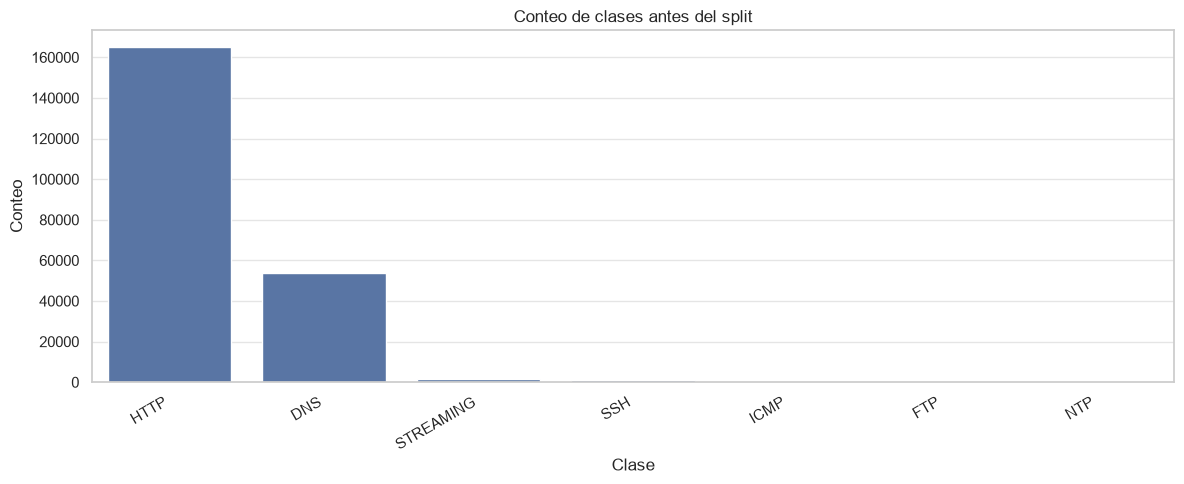

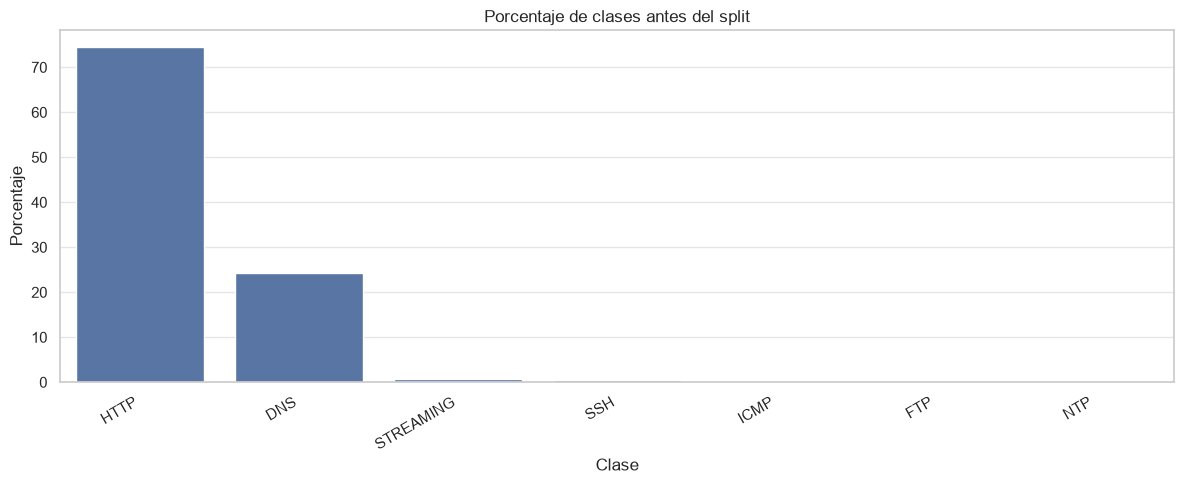

In [12]:
#! Muestra la distribucion real de clases despues de la limpieza minima.

class_distribution = display_class_distribution(
    df[TARGET_COLUMN],
    "Distribucion final de clases antes del split",
)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=class_distribution,
    x="class_name",
    y="count",
)
plt.title("Conteo de clases antes del split")
plt.xlabel("Clase")
plt.ylabel("Conteo")
plt.xticks(rotation=30, ha="right")
finalize_figure("01_class_distribution_counts")

plt.figure(figsize=(12, 5))
sns.barplot(
    data=class_distribution,
    x="class_name",
    y="percentage",
)
plt.title("Porcentaje de clases antes del split")
plt.xlabel("Clase")
plt.ylabel("Porcentaje")
plt.xticks(rotation=30, ha="right")
finalize_figure("02_class_distribution_percentage")


In [13]:
#! Calcula el ratio de desbalance entre la clase mayoritaria y minoritaria.

class_counts = df[TARGET_COLUMN].value_counts()
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()
imbalance_ratio = float(class_counts.max() / class_counts.min())

print(f"Clase mayoritaria: {majority_class} ({class_counts.max()} registros)")
print(f"Clase minoritaria: {minority_class} ({class_counts.min()} registros)")
print(f"Ratio de desbalance mayoritaria/minoritaria: {imbalance_ratio:,.2f}:1")

#! Este valor justifica usar macro-F1 y pesos por clase.


Clase mayoritaria: HTTP (164974 registros)
Clase minoritaria: NTP (23 registros)
Ratio de desbalance mayoritaria/minoritaria: 7,172.78:1


## Seccion 4: Preparacion de matrices X/y y split hold-out estratificado 70/30


### Codificacion estable del target


In [14]:
#! Construye matriz X en el orden canonico y vector y codificado.

X = build_feature_matrix(df)
y = encode_target(df[TARGET_COLUMN])
y_names = df[TARGET_COLUMN].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Mapping de clases: {CLASS_TO_ID}")


X shape: (221564, 4)
y shape: (221564,)
Mapping de clases: {'DNS': 0, 'FTP': 1, 'HTTP': 2, 'ICMP': 3, 'NTP': 4, 'SSH': 5, 'STREAMING': 6}


### Separacion estratificada 70/30


In [15]:
#! Split hold-out estratificado.
#! El 30% de prueba queda intacto hasta la evaluacion final.

X_train, X_test, y_train, y_test, y_train_names, y_test_names = train_test_split(
    X,
    y,
    y_names,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

train_distribution = display_class_distribution(
    pd.Series(y_train_names),
    "Distribucion de clases en entrenamiento 70%",
)

test_distribution = display_class_distribution(
    pd.Series(y_test_names),
    "Distribucion de clases en prueba 30%",
)


X_train shape: (155094, 4)
X_test shape: (66470, 4)
y_train shape: (155094,)
y_test shape: (66470,)
Distribucion de clases en entrenamiento 70%


,class_name,count,percentage,rank
0,HTTP,115481,74.458715,1
1,DNS,37486,24.169858,2
2,STREAMING,1041,0.671206,3
3,SSH,793,0.511303,4
4,ICMP,213,0.137336,5
5,FTP,64,0.041265,6
6,NTP,16,0.010316,7


Distribucion de clases en prueba 30%


,class_name,count,percentage,rank
0,HTTP,49493,74.459155,1
1,DNS,16065,24.168798,2
2,STREAMING,446,0.670979,3
3,SSH,340,0.511509,4
4,ICMP,92,0.138408,5
5,FTP,27,0.04062,6
6,NTP,7,0.010531,7


In [16]:
#! Verifica que el numero de folds sea viable para la clase minoritaria del entrenamiento.

validate_minority_support(pd.Series(y_train_names), N_SPLITS)

min_train_count = int(pd.Series(y_train_names).value_counts().min())
print(
    f"Soporte minimo en entrenamiento: {min_train_count}. "
    f"N_SPLITS={N_SPLITS} es viable porque {min_train_count} >= {N_SPLITS}."
)


Soporte minimo en entrenamiento: 16. N_SPLITS=5 es viable porque 16 >= 5.


In [17]:
#! Guarda un resumen del split para trazabilidad.

split_summary = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "train_rows": int(len(y_train)),
    "test_rows": int(len(y_test)),
    "feature_columns": FEATURE_COLUMNS,
    "target_column": TARGET_COLUMN,
    "class_to_id": CLASS_TO_ID,
    "train_distribution": train_distribution.to_dict(orient="records"),
    "test_distribution": test_distribution.to_dict(orient="records"),
}

save_json(OUTPUT_DIR / TRAIN_TEST_SPLIT_FILENAME, split_summary)
print(f"Resumen del split guardado en: {OUTPUT_DIR / TRAIN_TEST_SPLIT_FILENAME}")


Resumen del split guardado en: ../../../res/models/sdn_mpls_ml_train_test_split_summary.json


## Seccion 5: Optimizacion con Optuna usando 5-fold StratifiedKFold


### Configuracion de la optimizacion

La optimizacion sigue estas reglas:

- Optuna solo ve el 70% de entrenamiento.
- El 30% de prueba no se usa durante Optuna.
- Cada trial se evalua con 5 folds estratificados.
- La metrica objetivo es `macro-F1`.
- Cada fold entrena con `sample_weight` balanceado por clase.
- XGBoost usa `multi:softprob` para obtener probabilidades por clase.
- Early stopping se aplica dentro de cada fold usando la particion de validacion del fold.
- La cantidad final de arboles se deriva de la mediana de las mejores iteraciones del mejor trial.


In [18]:
#! Crea el objeto StratifiedKFold que se usara dentro de cada trial.

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

print(cv)


StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [19]:
def objective(trial: optuna.Trial) -> float:
    """Funcion objetivo de Optuna basada en macro-F1 promedio.

    Paso a paso:

    1. Solicita hiperparametros al trial.
    2. Crea listas para almacenar metricas por fold.
    3. Recorre los folds estratificados sobre X_train e y_train.
    4. Calcula pesos balanceados solo con el fold de entrenamiento.
    5. Entrena XGBoost con early stopping.
    6. Predice sobre el fold de validacion.
    7. Calcula macro-F1.
    8. Reporta el promedio parcial a Optuna.
    9. Permite pruning si Optuna decide detener el trial.
    10. Guarda mejores iteraciones y metricas como atributos del trial.
    11. Devuelve macro-F1 promedio.

    Args:
        trial: Trial actual de Optuna.

    Returns:
        Macro-F1 promedio de los folds.
    """
    #! Obtiene hiperparametros propuestos por Optuna.
    params = suggest_xgb_params(trial)

    #! Almacena macro-F1 de cada fold.
    fold_scores: list[float] = []

    #! Almacena la mejor iteracion de cada fold para el entrenamiento final.
    fold_best_iterations: list[int] = []

    #! Recorre las particiones estratificadas del conjunto de entrenamiento.
    for fold_index, (train_index, valid_index) in enumerate(cv.split(X_train, y_train), start=1):
        #! Separa datos del fold actual.
        X_fold_train = X_train[train_index]
        X_fold_valid = X_train[valid_index]
        y_fold_train = y_train[train_index]
        y_fold_valid = y_train[valid_index]

        #! Calcula pesos balanceados usando solo el fold de entrenamiento.
        sample_weights = compute_sample_weight(
            class_weight="balanced",
            y=y_fold_train,
        )

        #! Construye el modelo del trial con muchas rondas y early stopping.
        model = build_xgb_classifier(
            params=params,
            n_estimators=MAX_BOOSTING_ROUNDS,
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        )

        #! Entrena usando la validacion del fold como eval_set.
        model.fit(
            X_fold_train,
            y_fold_train,
            sample_weight=sample_weights,
            eval_set=[(X_fold_valid, y_fold_valid)],
            verbose=False,
        )

        #! Predice clases para la validacion del fold.
        y_fold_pred = model.predict(X_fold_valid)

        #! Calcula macro-F1 para no favorecer solo a HTTP y DNS.
        fold_macro_f1 = f1_score(
            y_fold_valid,
            y_fold_pred,
            average="macro",
            zero_division=0,
        )

        #! Registra el resultado del fold.
        fold_scores.append(float(fold_macro_f1))

        #! Recupera la mejor iteracion si el modelo la expone.
        best_iteration = getattr(model, "best_iteration", None)
        if best_iteration is None:
            best_iteration = MAX_BOOSTING_ROUNDS - 1

        #! Guarda la cantidad de arboles efectiva.
        fold_best_iterations.append(int(best_iteration) + 1)

        #! Reporta a Optuna el promedio parcial acumulado.
        trial.report(float(np.mean(fold_scores)), step=fold_index)

        #! Permite pruning si Optuna considera que el trial no promete.
        if trial.should_prune():
            raise optuna.TrialPruned()

    #! Calcula metricas agregadas del trial.
    mean_macro_f1 = float(np.mean(fold_scores))
    std_macro_f1 = float(np.std(fold_scores, ddof=1)) if len(fold_scores) > 1 else 0.0
    median_best_iteration = int(np.median(fold_best_iterations))

    #! Guarda informacion util para auditoria y entrenamiento final.
    trial.set_user_attr("fold_macro_f1_scores", fold_scores)
    trial.set_user_attr("fold_best_iterations", fold_best_iterations)
    trial.set_user_attr("mean_macro_f1", mean_macro_f1)
    trial.set_user_attr("std_macro_f1", std_macro_f1)
    trial.set_user_attr("median_best_iteration", median_best_iteration)

    #! Devuelve el valor que Optuna debe maximizar.
    return mean_macro_f1


In [20]:
#! Configura sampler y pruner de Optuna.

sampler = optuna.samplers.TPESampler(
    seed=RANDOM_STATE,
    multivariate=True,
)

pruner = optuna.pruners.MedianPruner(
    n_startup_trials=10,
    n_warmup_steps=2,
)

study = optuna.create_study(
    study_name=OPTUNA_STUDY_NAME,
    direction="maximize",
    sampler=sampler,
    pruner=pruner,
    storage=OPTUNA_STORAGE,
    load_if_exists=False,
)

print(study)


/var/folders/3c/vp72r8cx1kx1z2gvmfkybjqc0000gn/T/ipykernel_10316/1428016665.py:3: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(
[I 2026-08-03 16:21:10,390] A new study created in memory with name: sdnflow_xgboost_multiclass_macro_f1


In [21]:
#! Ejecuta la optimizacion de hiperparametros.
#! Este bloque puede tardar dependiendo del numero de trials y recursos CPU.

optimization_start = time.perf_counter()

study.optimize(
    objective,
    n_trials=N_OPTUNA_TRIALS,
    n_jobs=OPTUNA_N_JOBS,
    show_progress_bar=True,
)

optimization_seconds = time.perf_counter() - optimization_start

print(f"Optimizacion finalizada en {optimization_seconds / 60:.2f} minutos")
print(f"Mejor macro-F1 CV: {study.best_value:.6f}")
print("Mejores parametros:")
display(study.best_params)
print("Atributos del mejor trial:")
display(study.best_trial.user_attrs)


Best trial: 0. Best value: 0.877504:   1%|▏         | 1/75 [00:09<11:24,  9.25s/it]

[I 2026-08-03 16:21:39,554] Trial 0 finished with value: 0.8775039493385922 and parameters: {'max_depth': 4, 'learning_rate': 0.2133249073808361, 'min_child_weight': 12.057126287443763, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.7468055921327309, 'gamma': 1.5599452033620265, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 21.42302175774107, 'max_delta_step': 6.011150117432088}. Best is trial 0 with value: 0.8775039493385922.


Best trial: 0. Best value: 0.877504:   3%|▎         | 2/75 [01:03<43:35, 35.83s/it]

[I 2026-08-03 16:22:33,993] Trial 1 finished with value: 0.8775039493385922 and parameters: {'max_depth': 6, 'learning_rate': 0.010685033500506827, 'min_child_weight': 27.08160864249967, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.7637017332034828, 'gamma': 1.8182496720710062, 'reg_alpha': 4.4734294104626844e-07, 'reg_lambda': 0.033205591037519584, 'max_delta_step': 5.247564316322379}. Best is trial 0 with value: 0.8775039493385922.


Best trial: 0. Best value: 0.877504:   4%|▍         | 3/75 [01:33<39:43, 33.11s/it]

...

Best trial: 51. Best value: 0.892986: 100%|██████████| 75/75 [20:45<00:00, 16.61s/it]

[I 2026-08-03 16:42:15,737] Trial 74 finished with value: 0.8899215222601263 and parameters: {'max_depth': 4, 'learning_rate': 0.12162573461806286, 'min_child_weight': 6.646425458169461, 'subsample': 0.7549165679888273, 'colsample_bytree': 0.7133830983920125, 'gamma': 0.16193670913929728, 'reg_alpha': 0.0012402365710803326, 'reg_lambda': 0.01469854570115007, 'max_delta_step': 0.9310218546278362}. Best is trial 51 with value: 0.892986459628629.
Optimizacion finalizada en 20.76 minutos
Mejor macro-F1 CV: 0.892986
Mejores parametros:


{'max_depth': 3,
 'learning_rate': 0.2372833090616284,
 'min_child_weight': 2.687999601846242,
 'subsample': 0.7592168054493101,
 'colsample_bytree': 0.7137871020296106,
 'gamma': 0.20187059814092126,
 'reg_alpha': 0.10738404679294579,
 'reg_lambda': 0.005727698573355097,
 'max_delta_step': 4.147987470155511}

Atributos del mejor trial:


{'fold_macro_f1_scores': [0.8805757746969209,
  0.9007253858505717,
  0.9040507004811279,
  0.9011832976871809,
  0.8783971394273431],
 'fold_best_iterations': [548, 318, 437, 309, 475],
 'mean_macro_f1': 0.892986459628629,
 'std_macro_f1': 0.012413399245157193,
 'median_best_iteration': 437}

In [22]:
#! Exporta la tabla de trials de Optuna.

trials_df = study.trials_dataframe(attrs=("number", "value", "state", "params", "user_attrs"))
trials_output_path = OUTPUT_DIR / OPTUNA_TRIALS_FILENAME
trials_df.to_csv(trials_output_path, index=False, encoding="utf-8")

display(trials_df.sort_values("value", ascending=False).head(10))
print(f"Trials guardados en: {trials_output_path}")


,number,value,state,params_colsample_bytree,params_gamma,params_learning_rate,params_max_delta_step,params_max_depth,params_min_child_weight,params_reg_alpha,params_reg_lambda,params_subsample,user_attrs_fold_best_iterations,user_attrs_fold_macro_f1_scores,user_attrs_mean_macro_f1,user_attrs_median_best_iteration,user_attrs_std_macro_f1
51,51,0.892986,COMPLETE,0.713787,0.201871,0.237283,4.147987,3,2.688000,0.107384,0.005728,0.759217,"[548, 318, 437, 309, 475]","[0.8805757746969209, 0.9007253858505717, 0.904...",0.892986,437.0,0.012413
40,40,0.892620,COMPLETE,0.734644,0.140136,0.173294,0.274817,2,6.034796,0.020227,0.001267,0.836186,"[927, 963, 1188, 795, 1150]","[0.8787411790455162, 0.9007253858505717, 0.904...",0.892620,963.0,0.012890
64,64,0.891853,COMPLETE,0.701698,0.429123,0.154422,2.108538,2,2.155658,0.006257,0.002085,0.677770,"[555, 586, 646, 747, 410]","[0.8787411790455162, 0.9007253858505717, 0.892...",0.891853,586.0,0.009574
62,62,0.891479,COMPLETE,0.723902,0.326301,0.211775,6.323050,4,2.910603,0.000019,0.038714,0.912215,"[237, 373, 366, 496, 207]","[0.8746110176610429, 0.9007253858505717, 0.904...",0.891479,366.0,0.014466
42,42,0.891226,COMPLETE,0.703992,0.206377,0.219190,2.911171,3,3.645362,0.015828,0.007406,0.792155,"[375, 386, 437, 309, 348]","[0.8827433705473596, 0.9007253858505717, 0.904...",0.891226,375.0,0.011558
48,48,0.890771,COMPLETE,0.708894,0.014058,0.157798,5.133484,4,2.875399,0.000129,0.008267,0.869456,"[1073, 991, 520, 734, 433]","[0.888521563289374, 0.908723581348535, 0.89215...",0.890771,734.0,0.010900
57,57,0.890740,COMPLETE,0.706007,0.064340,0.160173,1.189006,2,4.915158,0.589366,0.003424,0.817637,"[927, 965, 1188, 1198, 1150]","[0.8787411790455162, 0.9007253858505717, 0.904...",0.890740,1150.0,0.011982
55,55,0.890713,COMPLETE,0.719103,0.296708,0.067238,4.744393,5,1.412499,0.001280,0.002330,0.878072,"[561, 863, 640, 766, 1150]","[0.8787411790455162, 0.9007253858505717, 0.894...",0.890713,766.0,0.011395
17,17,0.890561,COMPLETE,0.818870,0.460998,0.224575,2.018509,2,6.082708,0.019786,0.002282,0.842941,"[359, 595, 979, 246, 510]","[0.8746110176610429, 0.9007253858505717, 0.904...",0.890561,510.0,0.013300
69,69,0.890057,COMPLETE,0.723427,0.659779,0.238863,3.870622,3,1.779983,0.001166,0.457338,0.864109,"[325, 458, 300, 224, 433]","[0.8746110176610429, 0.9007253858505717, 0.879...",0.890057,325.0,0.012378


Trials guardados en: ../../../res/models/sdn_mpls_mp_optuna_trials.csv


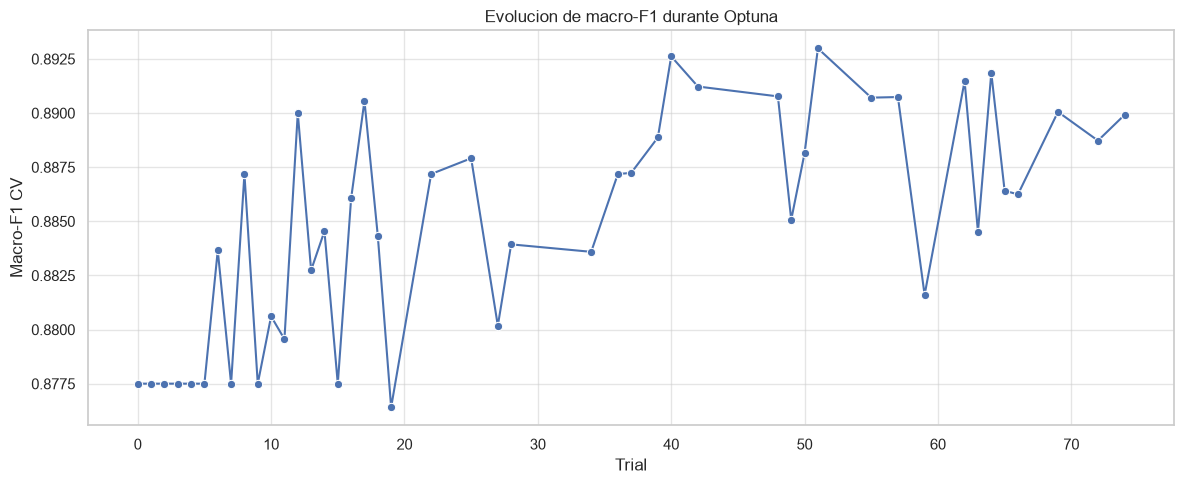

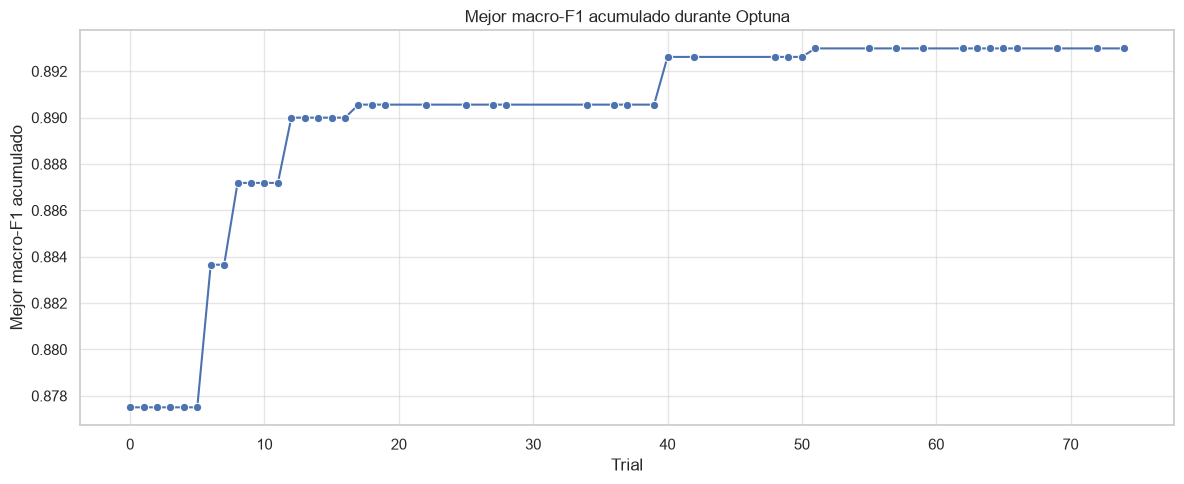

In [23]:
#! Visualiza la evolucion de Optuna.

completed_trials = trials_df.loc[trials_df["state"] == "COMPLETE"].copy()

if not completed_trials.empty:
    plt.figure(figsize=(12, 5))
    sns.lineplot(
        data=completed_trials,
        x="number",
        y="value",
        marker="o",
    )
    plt.title("Evolucion de macro-F1 durante Optuna")
    plt.xlabel("Trial")
    plt.ylabel("Macro-F1 CV")
    finalize_figure("03_optuna_macro_f1_evolution")

    plt.figure(figsize=(12, 5))
    best_so_far = completed_trials["value"].cummax()
    sns.lineplot(x=completed_trials["number"], y=best_so_far, marker="o")
    plt.title("Mejor macro-F1 acumulado durante Optuna")
    plt.xlabel("Trial")
    plt.ylabel("Mejor macro-F1 acumulado")
    finalize_figure("04_optuna_best_so_far")
else:
    print("No hay trials completos para graficar.")


## Seccion 6: Entrenamiento final sobre el 70% de entrenamiento


In [24]:
#! Prepara parametros finales.

best_params = clean_params_for_final_training(study.best_params)

#! Toma la mediana de mejores iteraciones del mejor trial.
#! Esto permite entrenar sobre todo el 70% sin crear un nuevo conjunto de validacion.
final_n_estimators = int(study.best_trial.user_attrs.get("median_best_iteration", MAX_BOOSTING_ROUNDS))

#! Aplica limites defensivos a la cantidad final de arboles.
final_n_estimators = max(1, min(final_n_estimators, MAX_BOOSTING_ROUNDS))

print(f"final_n_estimators derivado de CV: {final_n_estimators}")
display(best_params)


final_n_estimators derivado de CV: 437


{'max_depth': 3,
 'learning_rate': 0.2372833090616284,
 'min_child_weight': 2.687999601846242,
 'subsample': 0.7592168054493101,
 'colsample_bytree': 0.7137871020296106,
 'gamma': 0.20187059814092126,
 'reg_alpha': 0.10738404679294579,
 'reg_lambda': 0.005727698573355097,
 'max_delta_step': 4.147987470155511}

In [25]:
#! Calcula pesos balanceados usando todo el 70% de entrenamiento.

final_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train,
)

#! Entrena el modelo final sobre todo el conjunto de entrenamiento.
#! No se usa el test set durante este entrenamiento.

final_model = build_xgb_classifier(
    params=best_params,
    n_estimators=final_n_estimators,
    early_stopping_rounds=None,
)

final_training_start = time.perf_counter()

final_model.fit(
    X_train,
    y_train,
    sample_weight=final_sample_weights,
    verbose=True,
)

final_training_seconds = time.perf_counter() - final_training_start

print(f"Entrenamiento final completado en {final_training_seconds:.2f} segundos")
print(final_model)


Entrenamiento final completado en 2.59 segundos
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7137871020296106, device='cpu',
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='mlogloss', feature_types=None, feature_weights=None,
              gamma=0.20187059814092126, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2372833090616284,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=4.147987470155511, max_depth=3, max_leaves=None,
              min_child_weight=2.687999601846242, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=437,
              n_jobs=15, num_class=7, ...)


## Seccion 7: Evaluacion final sobre el 30% de prueba intacto


In [26]:
#! Genera predicciones y probabilidades sobre el test set.
#! Este es el primer uso del 30% de prueba para evaluar el modelo final.

test_probabilities = final_model.predict_proba(X_test)
validate_probability_matrix(test_probabilities)

y_test_pred = np.argmax(test_probabilities, axis=1)
test_confidence = np.max(test_probabilities, axis=1)

print(f"Probabilidades shape: {test_probabilities.shape}")
print(f"Confianza promedio: {test_confidence.mean():.6f}")
print(f"Confianza mediana: {np.median(test_confidence):.6f}")


Probabilidades shape: (66470, 7)
Confianza promedio: 0.999763
Confianza mediana: 0.999942


In [27]:
#! Calcula metricas globales.

final_accuracy = accuracy_score(y_test, y_test_pred)
final_macro_f1 = f1_score(y_test, y_test_pred, average="macro", zero_division=0)
final_weighted_f1 = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)

print(f"Accuracy: {final_accuracy:.6f}")
print(f"Macro-F1: {final_macro_f1:.6f}")
print(f"Weighted-F1: {final_weighted_f1:.6f}")


Accuracy: 0.999654
Macro-F1: 0.879647
Weighted-F1: 0.999723


### Reporte por clase


In [28]:
#! Genera reporte por clase con nombres originales.

target_names = EXPECTED_CLASSES

report_dict = classification_report(
    y_test,
    y_test_pred,
    labels=list(range(len(EXPECTED_CLASSES))),
    target_names=target_names,
    zero_division=0,
    output_dict=True,
)

report_df = pd.DataFrame(report_dict).transpose()
display(report_df)

print(
    classification_report(
        y_test,
        y_test_pred,
        labels=list(range(len(EXPECTED_CLASSES))),
        target_names=target_names,
        zero_division=0,
    )
)


,precision,recall,f1-score,support
DNS,1.000000,1.000000,1.000000,16065.000000
FTP,1.000000,1.000000,1.000000,27.000000
HTTP,0.999899,0.999636,0.999768,49493.000000
ICMP,1.000000,1.000000,1.000000,92.000000
NTP,0.111111,0.285714,0.160000,7.000000
SSH,1.000000,1.000000,1.000000,340.000000
STREAMING,0.995536,1.000000,0.997763,446.000000
accuracy,0.999654,0.999654,0.999654,0.999654
macro avg,0.872364,0.897907,0.879647,66470.000000
weighted avg,0.999801,0.999654,0.999723,66470.000000


              precision    recall  f1-score   support

         DNS       1.00      1.00      1.00     16065
         FTP       1.00      1.00      1.00        27
        HTTP       1.00      1.00      1.00     49493
        ICMP       1.00      1.00      1.00        92
         NTP       0.11      0.29      0.16         7
         SSH       1.00      1.00      1.00       340
   STREAMING       1.00      1.00      1.00       446

    accuracy                           1.00     66470
   macro avg       0.87      0.90      0.88     66470
weighted avg       1.00      1.00      1.00     66470



### Matriz de confusion


,DNS,FTP,HTTP,ICMP,NTP,SSH,STREAMING
DNS,16065,0,0,0,0,0,0
FTP,0,27,0,0,0,0,0
HTTP,0,0,49475,0,16,0,2
ICMP,0,0,0,92,0,0,0
NTP,0,0,5,0,2,0,0
SSH,0,0,0,0,0,340,0
STREAMING,0,0,0,0,0,0,446


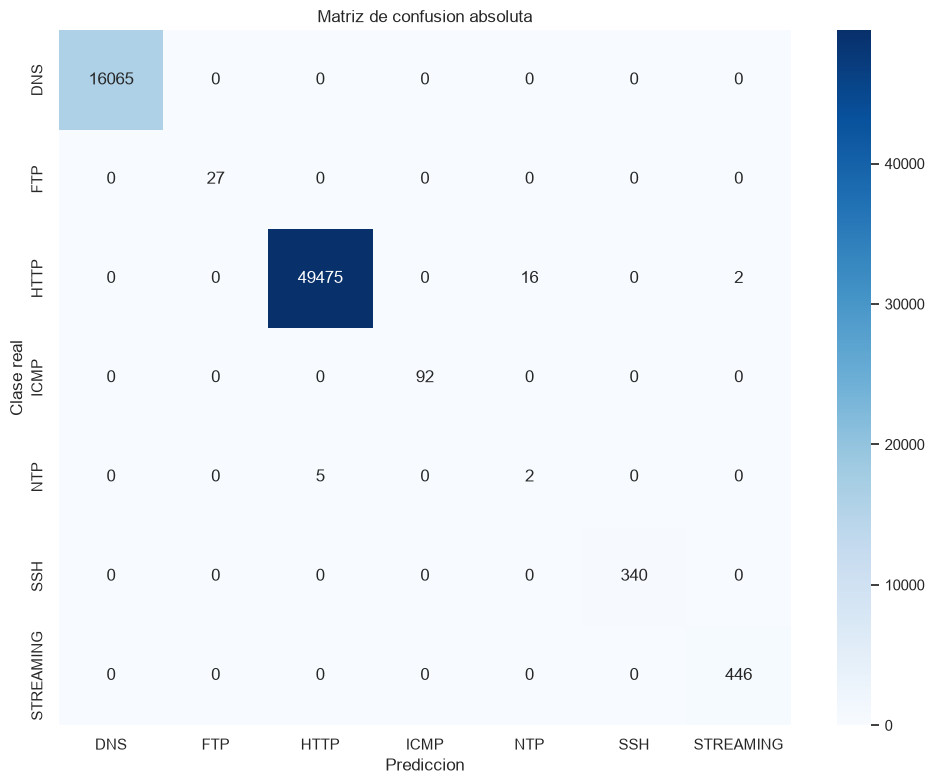

In [29]:
#! Calcula la matriz de confusion absoluta.

cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=list(range(len(EXPECTED_CLASSES))),
)

cm_df = pd.DataFrame(
    cm,
    index=EXPECTED_CLASSES,
    columns=EXPECTED_CLASSES,
)

display(cm_df)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
)
plt.title("Matriz de confusion absoluta")
plt.xlabel("Prediccion")
plt.ylabel("Clase real")
finalize_figure("05_confusion_matrix_absolute")


,DNS,FTP,HTTP,ICMP,NTP,SSH,STREAMING
DNS,1.0,0.0,0.000000,0.0,0.000000,0.0,0.00000
FTP,0.0,1.0,0.000000,0.0,0.000000,0.0,0.00000
HTTP,0.0,0.0,0.999636,0.0,0.000323,0.0,0.00004
ICMP,0.0,0.0,0.000000,1.0,0.000000,0.0,0.00000
NTP,0.0,0.0,0.714286,0.0,0.285714,0.0,0.00000
SSH,0.0,0.0,0.000000,0.0,0.000000,1.0,0.00000
STREAMING,0.0,0.0,0.000000,0.0,0.000000,0.0,1.00000


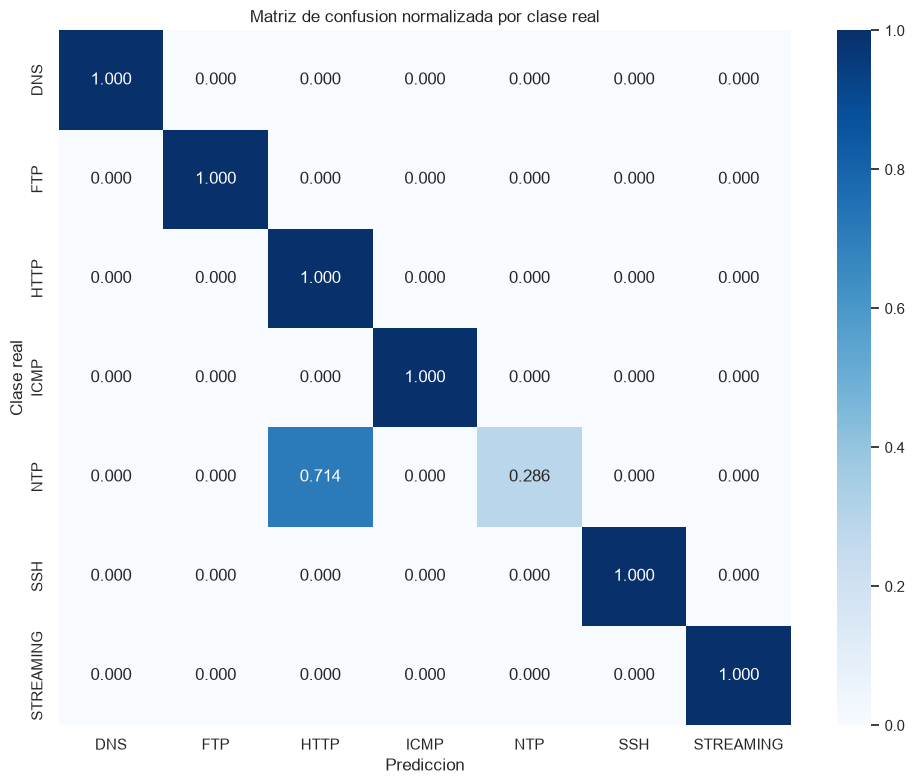

In [30]:
#! Calcula la matriz de confusion normalizada por clase real.

cm_normalized = confusion_matrix(
    y_test,
    y_test_pred,
    labels=list(range(len(EXPECTED_CLASSES))),
    normalize="true",
)

cm_normalized_df = pd.DataFrame(
    cm_normalized,
    index=EXPECTED_CLASSES,
    columns=EXPECTED_CLASSES,
)

display(cm_normalized_df)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized_df,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0,
    vmax=1,
)
plt.title("Matriz de confusion normalizada por clase real")
plt.xlabel("Prediccion")
plt.ylabel("Clase real")
finalize_figure("06_confusion_matrix_normalized")


### Analisis de errores por clase


In [31]:
#! Construye una tabla fila por fila para inspeccionar errores.

test_results = pd.DataFrame(
    {
        "true_id": y_test,
        "predicted_id": y_test_pred,
        "confidence": test_confidence,
    }
)

test_results["true_class"] = test_results["true_id"].map(lambda value: EXPECTED_CLASSES[int(value)])
test_results["predicted_class"] = test_results["predicted_id"].map(lambda value: EXPECTED_CLASSES[int(value)])
test_results["is_correct"] = test_results["true_id"].eq(test_results["predicted_id"])

error_summary = (
    test_results
    .groupby("true_class", observed=False)
    .agg(
        total=("is_correct", "size"),
        correct=("is_correct", "sum"),
        errors=("is_correct", lambda values: int((~values).sum())),
        mean_confidence=("confidence", "mean"),
    )
    .reset_index()
)

error_summary["recall_observed"] = error_summary["correct"] / error_summary["total"]

display(error_summary)


,true_class,total,correct,errors,mean_confidence,recall_observed
0,DNS,16065,16065,0,0.999906,1.000000
1,FTP,27,27,0,0.999783,1.000000
2,HTTP,49493,49475,18,0.999725,0.999636
3,ICMP,92,92,0,0.999946,1.000000
4,NTP,7,2,5,0.930585,0.285714
5,SSH,340,340,0,0.999880,1.000000
6,STREAMING,446,446,0,0.999835,1.000000


In [32]:
#! Muestra los errores mas frecuentes como pares real -> predicho.

error_pairs = (
    test_results
    .loc[~test_results["is_correct"]]
    .groupby(["true_class", "predicted_class"], observed=False)
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(error_pairs.head(20))


,true_class,predicted_class,count
0,HTTP,NTP,16
2,NTP,HTTP,5
1,HTTP,STREAMING,2


## Seccion 8: Importancia de variables y comportamiento del modelo


,feature,gain,weight
1,ip_proto,944.123108,224.0
3,dst_port,520.132996,737.0
2,src_port,263.096802,1752.0
0,eth_type,0.000000,0.0


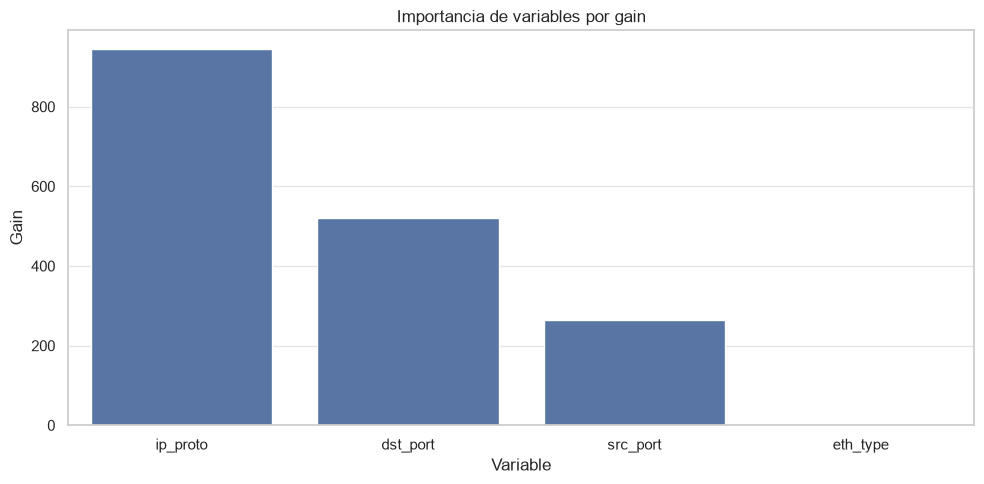

In [33]:
#! Extrae importancia de variables desde el booster final.

booster = final_model.get_booster()
importance_gain = booster.get_score(importance_type="gain")
importance_weight = booster.get_score(importance_type="weight")

importance_rows = []
for feature_index, feature_name in enumerate(FEATURE_COLUMNS):
    xgb_feature_name = f"f{feature_index}"
    importance_rows.append(
        {
            "feature": feature_name,
            "gain": float(importance_gain.get(xgb_feature_name, 0.0)),
            "weight": float(importance_weight.get(xgb_feature_name, 0.0)),
        }
    )

importance_df = pd.DataFrame(importance_rows).sort_values("gain", ascending=False)
display(importance_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x="feature", y="gain")
plt.title("Importancia de variables por gain")
plt.xlabel("Variable")
plt.ylabel("Gain")
finalize_figure("07_feature_importance_gain")


## Seccion 9: Exportacion del modelo, metadatos y metricas


In [34]:
#! Define rutas de salida principales.

model_output_path = OUTPUT_DIR / MODEL_FILENAME
metadata_output_path = OUTPUT_DIR / MODEL_METADATA_FILENAME
metrics_output_path = OUTPUT_DIR / FINAL_METRICS_FILENAME

print(f"Modelo: {model_output_path}")
print(f"Metadata: {metadata_output_path}")
print(f"Metricas: {metrics_output_path}")


Modelo: ../../../res/models/sdn_mpls_ml_model.json
Metadata: ../../../res/models/sdn_mpls_ml_model_meta.json
Metricas: ../../../res/models/sdn_mpls_ml_final_metrics.json


In [35]:
#! Guarda el modelo en formato nativo JSON de XGBoost.

final_model.save_model(model_output_path)

print(f"Modelo guardado en: {model_output_path}")


Modelo guardado en: ../../../res/models/sdn_mpls_ml_model.json


In [36]:
#! Crea metadata que debe viajar junto al modelo.
#! Esta metadata sera usada por la API de inferencia para reconstruir el vector.

model_metadata = {
    "schema_version": "1.0",
    "model_name": "sdnflow_xgboost_first_packet",
    "target_name": TARGET_COLUMN,
    "model_format": "xgboost_booster_json",
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "python_version": sys.version,
    "xgboost_version": xgb.__version__,
    "optuna_version": optuna.__version__,
    "feature_order": FEATURE_COLUMNS,
    "feature_types": {
        "eth_type": "integer",
        "ip_proto": "integer",
        "src_port": "integer",
        "dst_port": "integer",
    },
    "class_to_id": CLASS_TO_ID,
    "id_to_class": ID_TO_CLASS,
    "training_plan": {
        "holdout_split": "stratified_70_30",
        "test_size": TEST_SIZE,
        "optimization_metric": "macro_f1",
        "cv_strategy": "StratifiedKFold",
        "cv_folds": N_SPLITS,
        "optuna_trials": N_OPTUNA_TRIALS,
        "imbalance_strategy": "balanced_sample_weight",
        "final_n_estimators": final_n_estimators,
    },
    "best_params": best_params,
    "best_cv_macro_f1": float(study.best_value),
}

save_json(metadata_output_path, model_metadata)

display(model_metadata)
print(f"Metadata guardada en: {metadata_output_path}")


{'schema_version': '1.0',
 'model_name': 'sdnflow_xgboost_first_packet',
 'target_name': 'Category',
 'model_format': 'xgboost_booster_json',
 'created_at_utc': '2026-08-03T21:48:21.844833+00:00',
 'python_version': '3.13.13 (main, Apr  7 2026, 18:19:01) [Clang 21.0.0 (clang-2100.0.123.102)]',
 'xgboost_version': '3.3.0',
 'optuna_version': '4.9.0',
 'feature_order': ['eth_type', 'ip_proto', 'src_port', 'dst_port'],
 'feature_types': {'eth_type': 'integer',
  'ip_proto': 'integer',
  'src_port': 'integer',
  'dst_port': 'integer'},
 'class_to_id': {'DNS': 0,
  'FTP': 1,
  'HTTP': 2,
  'ICMP': 3,
  'NTP': 4,
  'SSH': 5,
  'STREAMING': 6},
 'id_to_class': {'0': 'DNS',
  '1': 'FTP',
  '2': 'HTTP',
  '3': 'ICMP',
  '4': 'NTP',
  '5': 'SSH',
  '6': 'STREAMING'},
 'training_plan': {'holdout_split': 'stratified_70_30',
  'test_size': 0.3,
  'optimization_metric': 'macro_f1',
  'cv_strategy': 'StratifiedKFold',
  'cv_folds': 5,
  'optuna_trials': 75,
  'imbalance_strategy': 'balanced_sample_we

Metadata guardada en: ../../../res/models/sdn_mpls_ml_model_meta.json


In [37]:
#! Crea y guarda el resumen de metricas finales.

final_metrics = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "dataset": {
        "data_path": str(DATA_PATH),
        "rows_after_preparation": int(len(df)),
        "feature_columns": FEATURE_COLUMNS,
        "target_column": TARGET_COLUMN,
    },
    "split": {
        "train_rows": int(len(y_train)),
        "test_rows": int(len(y_test)),
        "test_size": TEST_SIZE,
        "random_state": RANDOM_STATE,
    },
    "optimization": {
        "n_trials": N_OPTUNA_TRIALS,
        "n_splits": N_SPLITS,
        "best_cv_macro_f1": float(study.best_value),
        "best_trial_number": int(study.best_trial.number),
        "best_params": best_params,
        "best_trial_user_attrs": study.best_trial.user_attrs,
        "optimization_seconds": float(optimization_seconds),
    },
    "final_training": {
        "final_n_estimators": int(final_n_estimators),
        "final_training_seconds": float(final_training_seconds),
        "class_weighting": "compute_sample_weight(class_weight='balanced')",
    },
    "final_test_metrics": {
        "accuracy": float(final_accuracy),
        "macro_f1": float(final_macro_f1),
        "weighted_f1": float(final_weighted_f1),
    },
    "classification_report": report_dict,
    "confusion_matrix": cm_df.to_dict(),
    "confusion_matrix_normalized": cm_normalized_df.to_dict(),
    "feature_importance": importance_df.to_dict(orient="records"),
}

save_json(metrics_output_path, final_metrics)

print(f"Metricas finales guardadas en: {metrics_output_path}")


Metricas finales guardadas en: ../../../res/models/sdn_mpls_ml_final_metrics.json


### Validacion de carga del modelo exportado


In [38]:
#! Valida que el modelo exportado pueda cargarse y producir probabilidades.

loaded_model = XGBClassifier()
loaded_model.load_model(model_output_path)

loaded_probabilities = loaded_model.predict_proba(X_test[:10])
validate_probability_matrix(loaded_probabilities)

print("Validacion de carga del modelo exportado: correcta")
print(loaded_probabilities[:3])


Validacion de carga del modelo exportado: correcta
[[7.5507464e-06 1.0663904e-06 9.9994767e-01 7.7986542e-06 2.9198720e-06
  3.2759635e-06 2.9692850e-05]
 [5.4397005e-06 2.9759907e-05 9.9991179e-01 5.4911079e-06 2.0559100e-06
  2.5775103e-05 1.9687363e-05]
 [9.9995255e-01 4.9531905e-06 1.8304738e-05 1.0326407e-05 1.2424478e-07
  3.3802155e-06 1.0362988e-05]]
